In [1]:
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import (
    RFECV,
)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

In [2]:
DATA_PREFIX = "../data"
OUTPUT_PREFIX = "../output"

EXTRACT_TRAIN_PARQUET = f"{OUTPUT_PREFIX}/extract_train_v2.parquet"
EXTRACT_TEST_PARQUET = f"{OUTPUT_PREFIX}/extract_test_v2.parquet"
SUBMISSION_CSV = f"{DATA_PREFIX}/sample_submission.csv"


In [3]:
BANDS_S2 = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
# BANDS_S2_DIST = [f"{b}_DIST" for b in BANDS_S2]
BANDS_S1 = ["VV", "VH"]
BANDS_CHM = [
    # "CHM",
    "CHM_META",
    # "CHM_ETH",
    "CHM_ALS",
]
BANDS_TERRAIN = [
    # "elevation",
    "slope",
    "aspect",
    "tpi",
    "tri",
    "hillshade",
]
BANDS_LST = ["LST"]
BANDS_TREE = ["CANOPY_DENSITY", "TREE_RATIO"]
BANDS_AGB = ["AGB_GEDI", "AGB_ALS"]
# BANDS_S1_DIST = [f"{b}_DIST" for b in BANDS_S1]

INDICES = [
    dict(name="NDVI", band1="NIR", band2="RED"),
    dict(name="NDMI", band1="NIR", band2="SWIR1"),
    dict(name="NBR", band1="NIR", band2="SWIR2"),
    dict(name="NBR2", band1="SWIR1", band2="SWIR2"),
    dict(name="NDWI", band1="GREEN", band2="NIR"),
    dict(name="MNDWI", band1="GREEN", band2="SWIR1"),
    dict(name="MNDWI2", band1="GREEN", band2="SWIR2"),
    dict(name="RVI", band1="VV", band2="VH"),
]

INDICES_BANDS = [indi["name"] for indi in INDICES]
# INDICES_BANDS_DIST = [f"{b}_DIST" for b in INDICES_BANDS]

PREDICTORS = [
    *BANDS_S2,
    *BANDS_S1,
    *INDICES_BANDS,
    *BANDS_CHM,
    *BANDS_TREE,
    *BANDS_TERRAIN,
    *BANDS_LST,
    *BANDS_AGB
    # *BANDS_S2_DIST,
    # *BANDS_S1_DIST,
    # *INDICES_BANDS_DIST,
]

LABEL = "biomass"

PREDICTORS

['BLUE',
 'GREEN',
 'RED',
 'NIR',
 'SWIR1',
 'SWIR2',
 'VV',
 'VH',
 'NDVI',
 'NDMI',
 'NBR',
 'NBR2',
 'NDWI',
 'MNDWI',
 'MNDWI2',
 'RVI',
 'CHM_META',
 'CHM_ALS',
 'CANOPY_DENSITY',
 'TREE_RATIO',
 'slope',
 'aspect',
 'tpi',
 'tri',
 'hillshade',
 'LST',
 'AGB_GEDI',
 'AGB_ALS']

In [4]:
# load parquet extracted
train_df = gpd.read_parquet(EXTRACT_TRAIN_PARQUET).dropna()
train_df

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,A57,A58,A59,A60,A61,A62,A63,AGB_GEDI,AGB_ALS,TREE_RATIO
0,3137124.7416963745,1810803.9191588927,2020,28.742064,038052,POINT (-3.54712 38.43217),366.0,588.0,620.0,2545.0,...,-14,-43,-60,56,-10,8,-36,113.301270,56.061787,0.259686
1,3138084.7416963745,1808543.9191588927,2020,61.379017,038052,POINT (-3.53221 38.41357),305.0,540.0,401.0,3402.0,...,-42,-37,-55,52,-38,31,39,73.137436,75.136459,0.270767
2,3136834.7416963745,1809903.9191588927,2020,41.445705,038052,POINT (-3.54874 38.42368),464.0,710.0,748.0,2929.0,...,-31,-27,-62,52,-26,26,0,74.259979,59.050060,0.278183
3,3137594.7416963745,1810823.9191588927,2020,25.911734,038052,POINT (-3.54186 38.4331),622.0,848.0,1139.0,2380.0,...,20,-35,-47,66,-32,32,16,94.649872,66.291756,0.245272
4,3137914.7416963745,1808923.9191588927,2020,40.892021,038052,POINT (-3.53481 38.41668),281.0,514.0,387.0,2421.0,...,43,-54,-48,57,-21,-29,14,74.906807,56.946735,0.258520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5148498,3111814.7416963745,2243943.9191588927,2019,96.743500,035805,POINT (-4.70358 42.23347),371.0,607.0,566.0,2937.0,...,-30,-60,-53,50,-57,0,-41,80.114174,82.793846,0.421154
5148499,3111664.7416963745,2243933.9191588927,2019,58.634174,035805,POINT (-4.70534 42.23312),882.0,1252.0,1425.0,3500.0,...,-10,-51,-49,58,-61,18,-19,68.616600,63.931862,0.406098
5148501,3113104.7416963745,2243803.9191588927,2019,118.166924,035805,POINT (-4.68791 42.2345),380.0,564.0,578.0,3241.0,...,-19,-64,-40,40,-64,-31,-35,86.218414,93.326202,0.181319
5148502,3113074.7416963745,2243833.9191588927,2019,104.021767,035805,POINT (-4.68834 42.23471),307.0,510.0,479.0,3084.0,...,-22,-69,-47,37,-62,-32,-29,88.159515,96.633919,0.285560


In [5]:
# Generating indices
def generate_indices(table, band_suffix=""):
    for index_dict in INDICES:
        name = f"{index_dict['name']}{band_suffix}"
        band1 = f"{index_dict['band1']}{band_suffix}"
        band2 = f"{index_dict['band2']}{band_suffix}"
        table[name] = (
            ((table[band1] / 1e4) - (table[band2] / 1e4))
            / ((table[band1] / 1e4) + (table[band2] / 1e4))
            * 1e4
        )


generate_indices(train_df)
# generate_indices(train_df, "_DIST")

train_df

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,AGB_ALS,TREE_RATIO,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
0,3137124.7416963745,1810803.9191588927,2020,28.742064,038052,POINT (-3.54712 38.43217),366.0,588.0,620.0,2545.0,...,56.061787,0.259686,6082.148499,953.303206,3286.348212,2408.500590,-6246.409192,-5628.252788,-3724.653148,5634.005764
1,3138084.7416963745,1808543.9191588927,2020,61.379017,038052,POINT (-3.53221 38.41357),305.0,540.0,401.0,3402.0,...,75.136459,0.270767,7891.138575,2368.660244,5231.699127,3268.015171,-7260.273973,-5907.540735,-3271.028037,5745.654163
2,3136834.7416963745,1809903.9191588927,2020,41.445705,038052,POINT (-3.54874 38.42368),464.0,710.0,748.0,2929.0,...,59.050060,0.278183,5931.465869,908.752328,3172.925568,2331.396817,-6097.829074,-5493.494129,-3626.570916,5230.875258
3,3137594.7416963745,1810823.9191588927,2020,25.911734,038052,POINT (-3.54186 38.4331),622.0,848.0,1139.0,2380.0,...,66.291756,0.245272,3526.570048,-428.312890,1646.684610,2060.465116,-4745.972739,-5071.200232,-3362.035225,4729.829756
4,3137914.7416963745,1808923.9191588927,2020,40.892021,038052,POINT (-3.53481 38.41668),281.0,514.0,387.0,2421.0,...,56.946735,0.258520,7243.589744,2396.313364,4677.174901,2568.768515,-6497.444634,-4857.428714,-2614.942529,4161.585366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5148498,3111814.7416963745,2243943.9191588927,2019,96.743500,035805,POINT (-4.70358 42.23347),371.0,607.0,566.0,2937.0,...,82.793846,0.421154,6768.484156,1165.177723,3695.500117,2644.178455,-6574.492099,-5858.068918,-3802.960694,4750.430293
5148499,3111664.7416963745,2243933.9191588927,2019,58.634174,035805,POINT (-4.70534 42.23312),882.0,1252.0,1425.0,3500.0,...,63.931862,0.406098,4213.197970,1301.259283,3425.393172,2223.230490,-4730.639731,-3654.333502,-1557.653405,6197.623515
5148501,3113104.7416963745,2243803.9191588927,2019,118.166924,035805,POINT (-4.68791 42.2345),380.0,564.0,578.0,3241.0,...,93.326202,0.181319,6973.029589,1990.381058,4546.678636,2810.650888,-7035.479632,-5866.617809,-3659.359191,4710.860367
5148502,3113074.7416963745,2243833.9191588927,2019,104.021767,035805,POINT (-4.68834 42.23471),307.0,510.0,479.0,3084.0,...,96.633919,0.285560,7311.254561,2233.240777,4431.445952,2439.644219,-7161.936561,-5867.098865,-4000.000000,5334.750266


In [6]:
train_df_filter = train_df[(train_df["BLUE"] > 0) & (train_df["VV"] > 0)]
train_df_filter

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,AGB_ALS,TREE_RATIO,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
0,3137124.7416963745,1810803.9191588927,2020,28.742064,038052,POINT (-3.54712 38.43217),366.0,588.0,620.0,2545.0,...,56.061787,0.259686,6082.148499,953.303206,3286.348212,2408.500590,-6246.409192,-5628.252788,-3724.653148,5634.005764
1,3138084.7416963745,1808543.9191588927,2020,61.379017,038052,POINT (-3.53221 38.41357),305.0,540.0,401.0,3402.0,...,75.136459,0.270767,7891.138575,2368.660244,5231.699127,3268.015171,-7260.273973,-5907.540735,-3271.028037,5745.654163
2,3136834.7416963745,1809903.9191588927,2020,41.445705,038052,POINT (-3.54874 38.42368),464.0,710.0,748.0,2929.0,...,59.050060,0.278183,5931.465869,908.752328,3172.925568,2331.396817,-6097.829074,-5493.494129,-3626.570916,5230.875258
3,3137594.7416963745,1810823.9191588927,2020,25.911734,038052,POINT (-3.54186 38.4331),622.0,848.0,1139.0,2380.0,...,66.291756,0.245272,3526.570048,-428.312890,1646.684610,2060.465116,-4745.972739,-5071.200232,-3362.035225,4729.829756
4,3137914.7416963745,1808923.9191588927,2020,40.892021,038052,POINT (-3.53481 38.41668),281.0,514.0,387.0,2421.0,...,56.946735,0.258520,7243.589744,2396.313364,4677.174901,2568.768515,-6497.444634,-4857.428714,-2614.942529,4161.585366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5148498,3111814.7416963745,2243943.9191588927,2019,96.743500,035805,POINT (-4.70358 42.23347),371.0,607.0,566.0,2937.0,...,82.793846,0.421154,6768.484156,1165.177723,3695.500117,2644.178455,-6574.492099,-5858.068918,-3802.960694,4750.430293
5148499,3111664.7416963745,2243933.9191588927,2019,58.634174,035805,POINT (-4.70534 42.23312),882.0,1252.0,1425.0,3500.0,...,63.931862,0.406098,4213.197970,1301.259283,3425.393172,2223.230490,-4730.639731,-3654.333502,-1557.653405,6197.623515
5148501,3113104.7416963745,2243803.9191588927,2019,118.166924,035805,POINT (-4.68791 42.2345),380.0,564.0,578.0,3241.0,...,93.326202,0.181319,6973.029589,1990.381058,4546.678636,2810.650888,-7035.479632,-5866.617809,-3659.359191,4710.860367
5148502,3113074.7416963745,2243833.9191588927,2019,104.021767,035805,POINT (-4.68834 42.23471),307.0,510.0,479.0,3084.0,...,96.633919,0.285560,7311.254561,2233.240777,4431.445952,2439.644219,-7161.936561,-5867.098865,-4000.000000,5334.750266


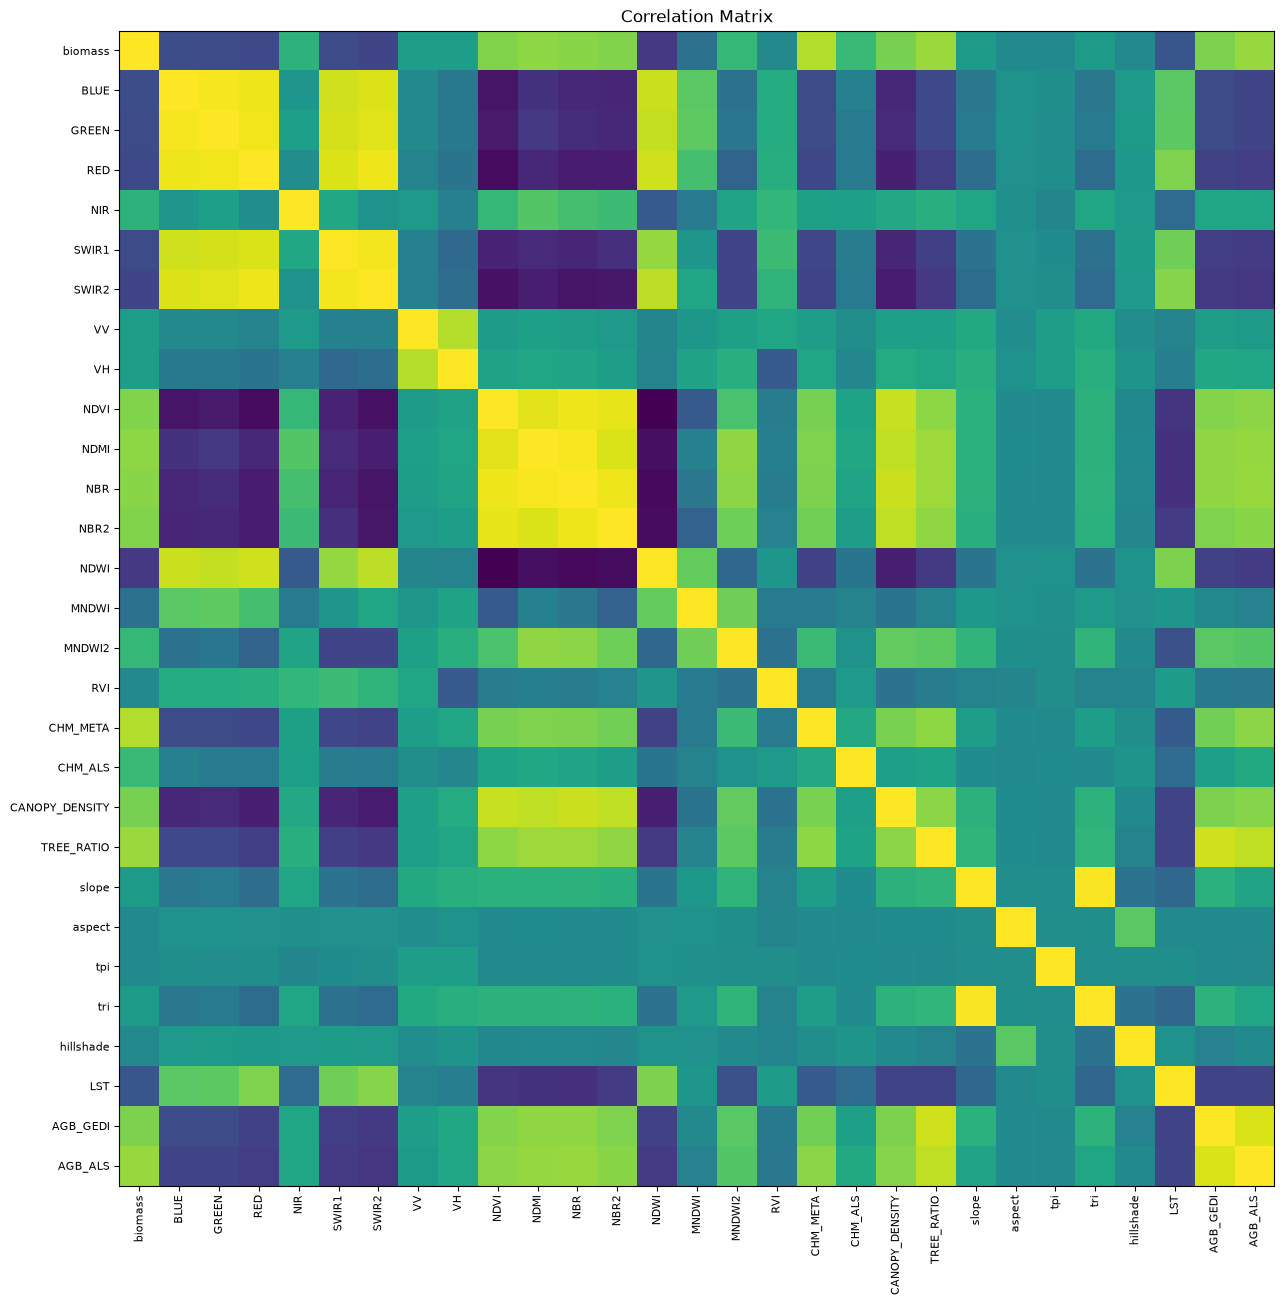

In [7]:
# generate correlation matrix
correlation = train_df[[LABEL, *PREDICTORS]].corr()

plt.figure(figsize=(15, 15))
plt.imshow(correlation)
plt.title("Correlation Matrix")
plt.xticks(range(len([LABEL, *PREDICTORS])), [LABEL, *PREDICTORS], size=8, rotation=90)
plt.yticks(range(len([LABEL, *PREDICTORS])), [LABEL, *PREDICTORS], size=8)
plt.show()


In [8]:
# split train and test data
train, test = train_test_split(train_df_filter, test_size=0.3)

In [9]:
# train limit sample
train_limit = train.sample(10_000)
test_limit = test.sample(1000)
train_limit

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,AGB_ALS,TREE_RATIO,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
4636039,3495494.7416963745,2013243.9191588927,2016,70.094818,074000,POINT (0.24158 40.73788),808.0,1104.0,1182.0,2418.0,...,87.592216,0.692677,3433.333333,-349.231690,1283.247783,1625.196144,-3730.834753,-4027.589938,-2570.659489,5124.153499
3862974,3525764.7416963745,2016793.9191588927,2016,14.137699,076991,POINT (0.59158 40.80427),1320.0,2044.0,2320.0,3653.0,...,16.732710,0.166594,2231.709359,16.451878,1565.616590,1549.563838,-2824.293488,-2809.146878,-1316.907392,6943.925234
3126532,3041094.7416963745,1902193.9191588927,2019,65.117920,028515,POINT (-4.807 39.08352),320.0,599.0,485.0,3377.0,...,72.525124,0.271528,7488.348006,2360.907760,4929.266136,2906.617192,-6986.921529,-5539.836188,-3138.602520,5464.190981
3145896,3112194.7416963745,1899593.9191588927,2019,5.154134,035690,POINT (-3.99464 39.18172),1265.0,1685.0,2170.0,3391.0,...,10.804896,0.077670,2195.648265,-1075.141466,-32.333921,1043.170188,-3360.914106,-4281.350755,-3389.564535,5056.818182
3404110,3203974.7416963745,1818463.9191588927,2019,5.266126,044633,POINT (-2.80698 38.60472),1236.0,1768.0,2491.0,3884.0,...,10.917814,0.032440,2185.098039,-661.216639,766.458766,1420.476497,-3743.807502,-4298.613351,-3065.306923,5630.689207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589891,3739914.7416963745,2112243.9191588927,2016,34.834549,098252,POINT (3.01516 41.87116),261.0,504.0,396.0,2374.0,...,35.471447,0.228782,7140.794224,1443.721379,4288.293711,3032.305433,-6497.567755,-5577.007459,-3062.629043,4229.691877
1860841,3083844.7416963745,1816723.9191588927,2019,25.307322,032672,POINT (-4.15725 38.39757),692.0,1015.0,1398.0,2502.0,...,63.251732,0.197827,2830.769231,-931.496919,701.454234,1622.350674,-4228.035257,-4964.028777,-3634.368140,4925.074925
4361944,3713184.7416963745,2142583.9191588927,2016,94.655060,095571,POINT (2.6626 42.12102),229.0,430.0,282.0,2533.0,...,156.520004,0.643652,7996.447602,2706.295460,5920.804525,3827.864955,-7097.536281,-5435.244161,-2029.657090,4476.093591
3719437,3068284.7416963745,1887353.9191588927,2019,50.612068,031201,POINT (-4.46925 38.99895),699.0,1176.0,1635.0,3418.0,...,101.338348,0.292789,3528.596873,159.013226,2438.136827,2287.994062,-4880.278624,-4758.190328,-2771.972956,4878.819810


In [10]:
min_features_to_select = 3
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=cv,
    min_features_to_select=min_features_to_select,
    scoring="neg_mean_squared_error",
)
rfecv.fit(train_limit[PREDICTORS], train_limit[LABEL])

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",3
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'neg_mean_squared_error'
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_features,) Standard deviation of scores over the folds.n_features : ndarray of shape (n_subsets_of_features,) Number of features used at each step

In [16]:
SELECTED_PREDICTORS = np.array(PREDICTORS)[rfecv.support_]
SELECTED_PREDICTORS

array(['BLUE', 'GREEN', 'RED', 'NIR', 'SWIR1', 'SWIR2', 'VV', 'VH',
       'NDVI', 'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI', 'MNDWI2',
       'CHM_META', 'CHM_ALS', 'CANOPY_DENSITY', 'TREE_RATIO', 'slope',
       'aspect', 'tpi', 'tri', 'hillshade', 'LST', 'AGB_GEDI', 'AGB_ALS'],
      dtype='<U14')

In [17]:
MODEL_NAME = f"XGB_v1_{datetime.now().timestamp()}"
model = XGBRegressor(n_estimators=100, max_depth=16)
model.fit(train[SELECTED_PREDICTORS], train[LABEL])

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [18]:
total = sum(model.feature_importances_)
print("Feature importance")
pd.Series(dict(zip(model.feature_names_in_, model.feature_importances_ / total * 100)))

Feature importance


BLUE               0.180314
GREEN              0.456557
RED                0.299339
NIR                0.352353
SWIR1              0.537910
SWIR2              0.574351
VV                 0.334717
VH                 0.339781
NDVI               0.576386
NDMI               0.455243
NBR                0.480353
NBR2               0.624441
NDWI              13.820185
MNDWI              0.426094
MNDWI2             0.399753
CHM_META          59.970768
CHM_ALS            7.506951
CANOPY_DENSITY     0.650283
TREE_RATIO         2.183743
slope              0.435667
aspect             0.537127
tpi                0.344274
tri                0.814038
hillshade          0.678391
LST                1.223040
AGB_GEDI           0.564633
AGB_ALS            5.233310
dtype: float32

In [ ]:
test_apply = model.predict(test[SELECTED_PREDICTORS])
r2 = np.corrcoef(test[LABEL], test_apply)[0, 1] ** 2
mae = mean_absolute_error(test[LABEL], test_apply)
rmse = root_mean_squared_error(test[LABEL], test_apply)
print(f"R^2={r2}", f"MAE={mae}", f"RMSE={rmse}")

In [ ]:
test_df = gpd.read_parquet(EXTRACT_TEST_PARQUET)
test_df

,row_id,tile_id,x,y,year,geometry,BLUE,GREEN,RED,NIR,...,elevation,CANOPY_DENSITY,CHM_META,CHM_ALS,slope,aspect,tri,tpi,hillshade,LST
0,028631_3040064_2251003,028631,3040064.7416963745,2251003.9191588927,2021,POINT (-5.57242 42.1662),147.0,318.0,152.0,3368.0,...,727,93,17,30.964409,7.375380,163.610458,6.782330,-1.250,170.0,23.340981
1,028631_3041214_2252063,028631,3041214.7416963745,2252063.9191588927,2021,POINT (-5.56121 42.17768),155.0,318.0,167.0,3011.0,...,737,94,20,26.640724,6.659468,0.000000,5.196152,-0.375,186.0,27.931381
2,028631_3041184_2251693,028631,3041184.7416963745,2251693.9191588927,2021,POINT (-5.56071 42.17436),159.0,330.0,148.0,4007.0,...,725,97,10,28.928268,4.745601,15.255112,4.795832,-1.125,182.0,23.135900
3,028631_3039864_2250783,028631,3039864.7416963745,2250783.9191588927,2021,POINT (-5.57428 42.16389),163.0,329.0,167.0,3221.0,...,727,92,23,32.106686,3.169812,23.198593,3.162278,-0.500,180.0,23.108555
4,028631_3040224_2251483,028631,3040224.7416963745,2251483.9191588927,2021,POINT (-5.57163 42.17073),139.0,276.0,123.0,4183.0,...,732,98,17,29.213942,5.584134,206.565048,4.472136,0.500,181.0,24.838074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,061751_3374644_2043173,061751,3374644.7416963745,2043173.9191588927,2020,POINT (-1.21909 40.85472),289.0,583.0,396.0,4034.0,...,1025,76,0,9.276945,2.943097,8.130104,2.236068,0.125,182.0,36.555046
45015,061751_3374594_2043203,061751,3374594.7416963745,2043203.9191588927,2020,POINT (-1.21972 40.85492),686.0,1111.0,1201.0,4128.0,...,1023,53,0,16.030308,6.864422,345.963745,5.291502,-0.250,189.0,38.110245
45016,061751_3374624_2043173,061751,3374624.7416963745,2043173.9191588927,2020,POINT (-1.21932 40.85469),286.0,574.0,375.0,3594.0,...,1025,77,11,8.037519,4.162167,0.000000,3.464102,0.000,184.0,38.110245
45017,061751_3374614_2043223,061751,3374614.7416963745,2043223.9191588927,2020,POINT (-1.21952 40.85512),210.0,405.0,271.0,3095.0,...,1022,70,14,16.777363,4.120336,315.000000,3.605551,-0.625,187.0,38.086319


In [ ]:
generate_indices(test_df)
# generate_indices(test_df, "_DIST")
test_df

,row_id,tile_id,x,y,year,geometry,BLUE,GREEN,RED,NIR,...,hillshade,LST,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
0,028631_3040064_2251003,028631,3040064.7416963745,2251003.9191588927,2021,POINT (-5.57242 42.1662),147.0,318.0,152.0,3368.0,...,170.0,23.340981,9136.363636,4451.834370,7144.311530,3948.220065,-8274.552360,-6052.141527,-2764.505119,6313.488059
1,028631_3041214_2252063,028631,3041214.7416963745,2252063.9191588927,2021,POINT (-5.56121 42.17768),155.0,318.0,167.0,3011.0,...,186.0,27.931381,8949.024544,4112.959925,6963.380282,3994.428969,-8089.516371,-5959.339263,-2578.763127,5957.873621
2,028631_3041184_2251693,028631,3041184.7416963745,2251693.9191588927,2021,POINT (-5.56071 42.17436),159.0,330.0,148.0,4007.0,...,182.0,23.135900,9287.605295,5477.018154,7836.634765,4133.977067,-8478.210745,-5602.931379,-1911.764706,5052.573326
3,028631_3039864_2250783,028631,3039864.7416963745,2250783.9191588927,2021,POINT (-5.57428 42.16389),163.0,329.0,167.0,3221.0,...,180.0,23.108555,9014.167651,4192.553426,7042.328042,4043.686734,-8146.478873,-6004.857316,-2590.090090,5794.743429
4,028631_3040224_2251483,028631,3040224.7416963745,2251483.9191588927,2021,POINT (-5.57163 42.17073),139.0,276.0,123.0,4183.0,...,181.0,24.838074,9428.704134,5599.477904,8131.772865,4649.286158,-8762.054272,-6208.791209,-2192.362093,6947.230702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,061751_3374644_2043173,061751,3374644.7416963745,2043173.9191588927,2020,POINT (-1.21909 40.85472),289.0,583.0,396.0,4034.0,...,182.0,36.555046,8212.189616,3183.006536,5491.551459,2797.546012,-7474.550574,-5631.322593,-3363.688105,5631.067961
45015,061751_3374594_2043203,061751,3374594.7416963745,2043203.9191588927,2020,POINT (-1.21972 40.85492),686.0,1111.0,1201.0,4128.0,...,189.0,38.110245,5492.587728,1806.091806,3446.254072,1749.026041,-5758.732583,-4411.468813,-2885.046430,5997.161107
45016,061751_3374624_2043173,061751,3374624.7416963745,2043173.9191588927,2020,POINT (-1.21932 40.85469),286.0,574.0,375.0,3594.0,...,184.0,38.110245,8110.355253,2575.227432,4937.655860,2706.586826,-7245.681382,-5741.839763,-3593.750000,5781.990521
45017,061751_3374614_2043223,061751,3374614.7416963745,2043223.9191588927,2020,POINT (-1.21952 40.85512),210.0,405.0,271.0,3095.0,...,187.0,38.086319,8389.780154,3823.135328,6454.013822,3492.682927,-7685.714286,-5469.798658,-2444.029851,5522.914219


In [ ]:
submission_df = pd.read_csv(SUBMISSION_CSV)
submission_df

,Id,Expected
0,028631_3040064_2251003,0.0
1,028631_3041214_2252063,0.0
2,028631_3041184_2251693,0.0
3,028631_3039864_2250783,0.0
4,028631_3040224_2251483,0.0
...,...,...
45014,061751_3374644_2043173,0.0
45015,061751_3374594_2043203,0.0
45016,061751_3374624_2043173,0.0
45017,061751_3374614_2043223,0.0


In [ ]:
submission_df["Expected"] = model.predict(test_df[SELECTED_PREDICTORS])
submission_df


,Id,Expected
0,028631_3040064_2251003,344.673615
1,028631_3041214_2252063,334.584869
2,028631_3041184_2251693,288.061218
3,028631_3039864_2250783,355.085632
4,028631_3040224_2251483,361.228790
...,...,...
45014,061751_3374644_2043173,50.205017
45015,061751_3374594_2043203,136.901108
45016,061751_3374624_2043173,110.572304
45017,061751_3374614_2043223,192.013794


In [ ]:
RESULT_CSV = f"{OUTPUT_PREFIX}/results_{MODEL_NAME}.csv"
submission_df.to_csv(RESULT_CSV, index=False)

MODEL_NAME

'XGB_v1_1787234394.925927'